In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import PartialDependenceDisplay

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")


In [4]:
df = pd.read_csv("station_summary.csv")
print("Raw shape:", df.shape)
df.head()


Raw shape: (242417, 25)


,id,name,city,state_province,country_code,latitude,longitude,ports,power_kw,power_class,...,SUV,Pickup,Sedan,Van,SUV_pct,Pickup_pct,Sedan_pct,Van_pct,mostly_fast_dc,high_ev_count
0,2389,Los Angeles Convention Center,Los Angeles,CA,US,34.040539,-118.271387,1,3.7,AC_L1_(<7.5kW),...,6,3,2,0,54.545455,27.272727,18.181818,0.0,False,True
1,2391,LADWP - John Ferraro Building,Los Angeles,CA,US,34.059133,-118.248589,1,50.0,DC_FAST_(50-149kW),...,6,3,2,0,54.545455,27.272727,18.181818,0.0,True,True
2,2396,State Capitol Parking Garage,Sacramento,CA,US,38.576769,-121.495022,1,3.7,AC_L1_(<7.5kW),...,6,3,2,0,54.545455,27.272727,18.181818,0.0,False,True
3,2399,CITYOFSANTAROSA,Santa Rosa,CA,US,38.438052,-122.711357,1,NaN,UNKNOWN,...,6,3,2,0,54.545455,27.272727,18.181818,0.0,False,True
4,2441,City of Pasadena - De Lacey Garage,Pasadena,CA,US,34.145138,-118.152655,1,3.7,AC_L1_(<7.5kW),...,6,3,2,0,54.545455,27.272727,18.181818,0.0,False,True


In [5]:
#Building Charging Time Varible
df["power_kw"] = pd.to_numeric(df["power_kw"], errors="coerce")
df["avg_battery"] = pd.to_numeric(df["avg_battery"], errors="coerce")

# invalid power
df.loc[df["power_kw"] <= 0, "power_kw"] = np.nan

df["charge_time_est_mins"] = (df["avg_battery"] / df["power_kw"]) * 60

print("Missing charging time before drop:", df["charge_time_est_mins"].isna().sum())
df = df.dropna(subset=["charge_time_est_mins"]).reset_index(drop=True)
print("After drop:", df.shape)

# remove extreme outliers (1%–99%)
Q1 = df["charge_time_est_mins"].quantile(0.01)
Q3 = df["charge_time_est_mins"].quantile(0.99)
df = df[(df["charge_time_est_mins"] >= Q1) & (df["charge_time_est_mins"] <= Q3)].reset_index(drop=True)
print("After outlier removal:", df.shape)
df[["avg_battery", "power_kw", "charge_time_est_mins"]].describe()



Missing charging time before drop: 35689
After drop: (206728, 26)
After outlier removal: (203613, 26)


,avg_battery,power_kw,charge_time_est_mins
count,203613.000000,203613.000000,203613.000000
mean,80.224190,27.799573,682.358308
std,6.447635,49.678798,582.203233
min,75.000000,2.700000,15.000000
25%,75.000000,3.700000,204.545455
50%,75.000000,11.000000,409.090909
75%,88.181818,22.000000,1429.975430
max,88.181818,351.000000,1763.636364


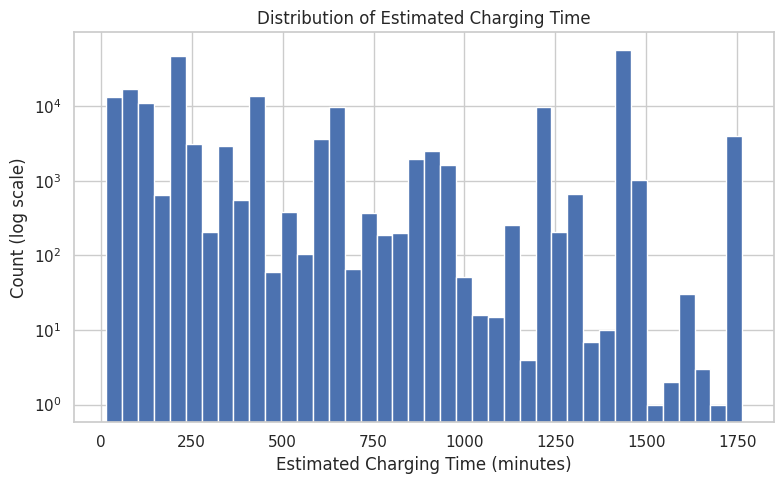

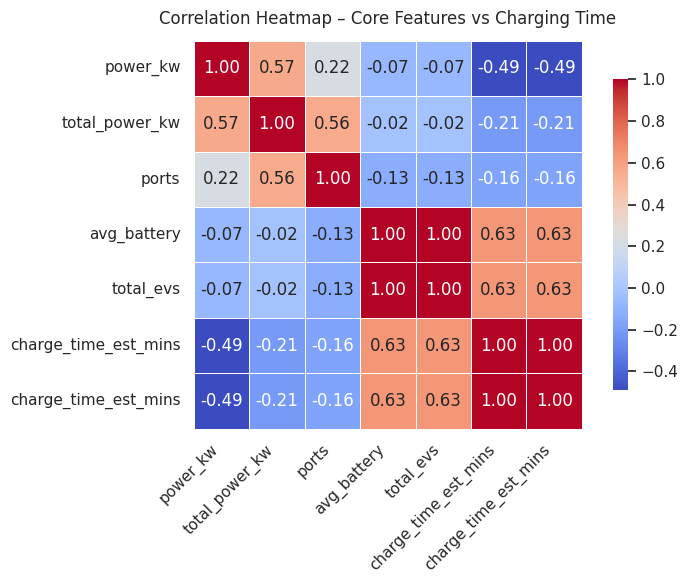

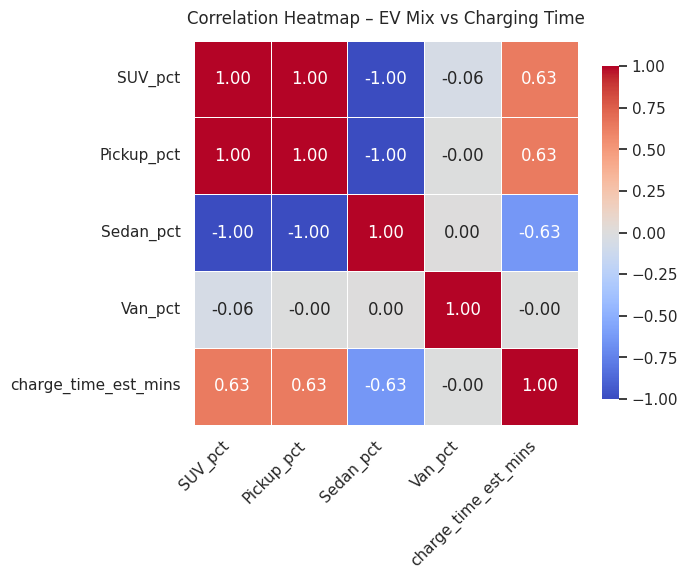

In [6]:
# Histogram of charging time
plt.figure(figsize=(8,5))
plt.hist(df["charge_time_est_mins"], bins=40)
plt.yscale("log")
plt.xlabel("Estimated Charging Time (minutes)")
plt.ylabel("Count (log scale)")
plt.title("Distribution of Estimated Charging Time")
plt.tight_layout()
plt.show()

# Features we will use
features = [
    "power_kw",
    "total_power_kw",
    "ports",
    "avg_battery",
    "total_evs",
    "charge_time_est_mins"
]
target = "charge_time_est_mins"

sns.set(style="white")
core_features = features + [target]

corr1 = df[core_features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr1,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)

plt.title("Correlation Heatmap – Core Features vs Charging Time", pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

ev_mix_features = ["SUV_pct", "Pickup_pct", "Sedan_pct", "Van_pct"]

corr2 = df[ev_mix_features + ["charge_time_est_mins"]].corr()

plt.figure(figsize=(7,6))
sns.heatmap(
    corr2,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)

plt.title("Correlation Heatmap – EV Mix vs Charging Time", pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
#Feature Matrix for X and Y
X = df[features]
y = df[target]

# one-hot encode any categoricals (none here, but safe)
X_encoded = pd.get_dummies(X, drop_first=True)

# ensure numeric & impute
X_encoded = X_encoded.apply(pd.to_numeric, errors="coerce")
X_encoded = X_encoded.fillna(X_encoded.median())

print("X_encoded shape:", X_encoded.shape)
X_encoded.head()

X_encoded shape: (203613, 19)


,ports,power_kw,total_power_kw,total_evs,avg_battery,SUV,Pickup,Sedan,Van,SUV_pct,Pickup_pct,Sedan_pct,Van_pct,latitude,longitude,power_class_AC_L1_(<7.5kW),power_class_AC_L2_(7.5-21kW),power_class_DC_FAST_(50-149kW),power_class_DC_ULTRA_(>=150kW)
0,1,3.7,3.7,11,88.181818,6,3,2,0,54.545455,27.272727,18.181818,0.0,34.040539,-118.271387,True,False,False,False
1,1,50.0,50.0,11,88.181818,6,3,2,0,54.545455,27.272727,18.181818,0.0,34.059133,-118.248589,False,False,True,False
2,1,3.7,3.7,11,88.181818,6,3,2,0,54.545455,27.272727,18.181818,0.0,38.576769,-121.495022,True,False,False,False
3,1,3.7,3.7,11,88.181818,6,3,2,0,54.545455,27.272727,18.181818,0.0,34.145138,-118.152655,True,False,False,False
4,1,3.7,3.7,11,88.181818,6,3,2,0,54.545455,27.272727,18.181818,0.0,34.145119,-118.150133,True,False,False,False


In [ ]:
clean_cols = (
    X_encoded.columns
    .astype(str)
    .str.replace(r"[<>\[\]\(\)]", "_", regex=True)
    .str.replace(r"__+", "_", regex=True)
    .str.strip("_")
)

X_encoded.columns = clean_cols
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)


Train shape: (162890, 19) | Test shape: (40723, 19)


In [ ]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    mse_train = mean_squared_error(y_tr, y_pred_train)
    mse_test  = mean_squared_error(y_te, y_pred_test)

    rmse_train = np.sqrt(mse_train)
    rmse_test  = np.sqrt(mse_test)
    mae_test   = mean_absolute_error(y_te, y_pred_test)
    r2_test    = r2_score(y_te, y_pred_test)

    print(f"\n{name}")
    print("-" * len(name))
    print(f"RMSE train: {rmse_train:.3f}")
    print(f"RMSE test : {rmse_test:.3f}")
    print(f"MAE test  : {mae_test:.3f}")
    print(f"R² test   : {r2_test:.3f}")

    return {
        "model": name,
        "RMSE_train": rmse_train,
        "RMSE_test": rmse_test,
        "MAE_test": mae_test,
        "R2_test": r2_test
    }

results = []


Fitting 3 folds for each of 45 candidates, totalling 135 fits

Decision Tree
-------------
RMSE train: 0.075
RMSE test : 0.466
MAE test  : 0.014
R² test   : 1.000


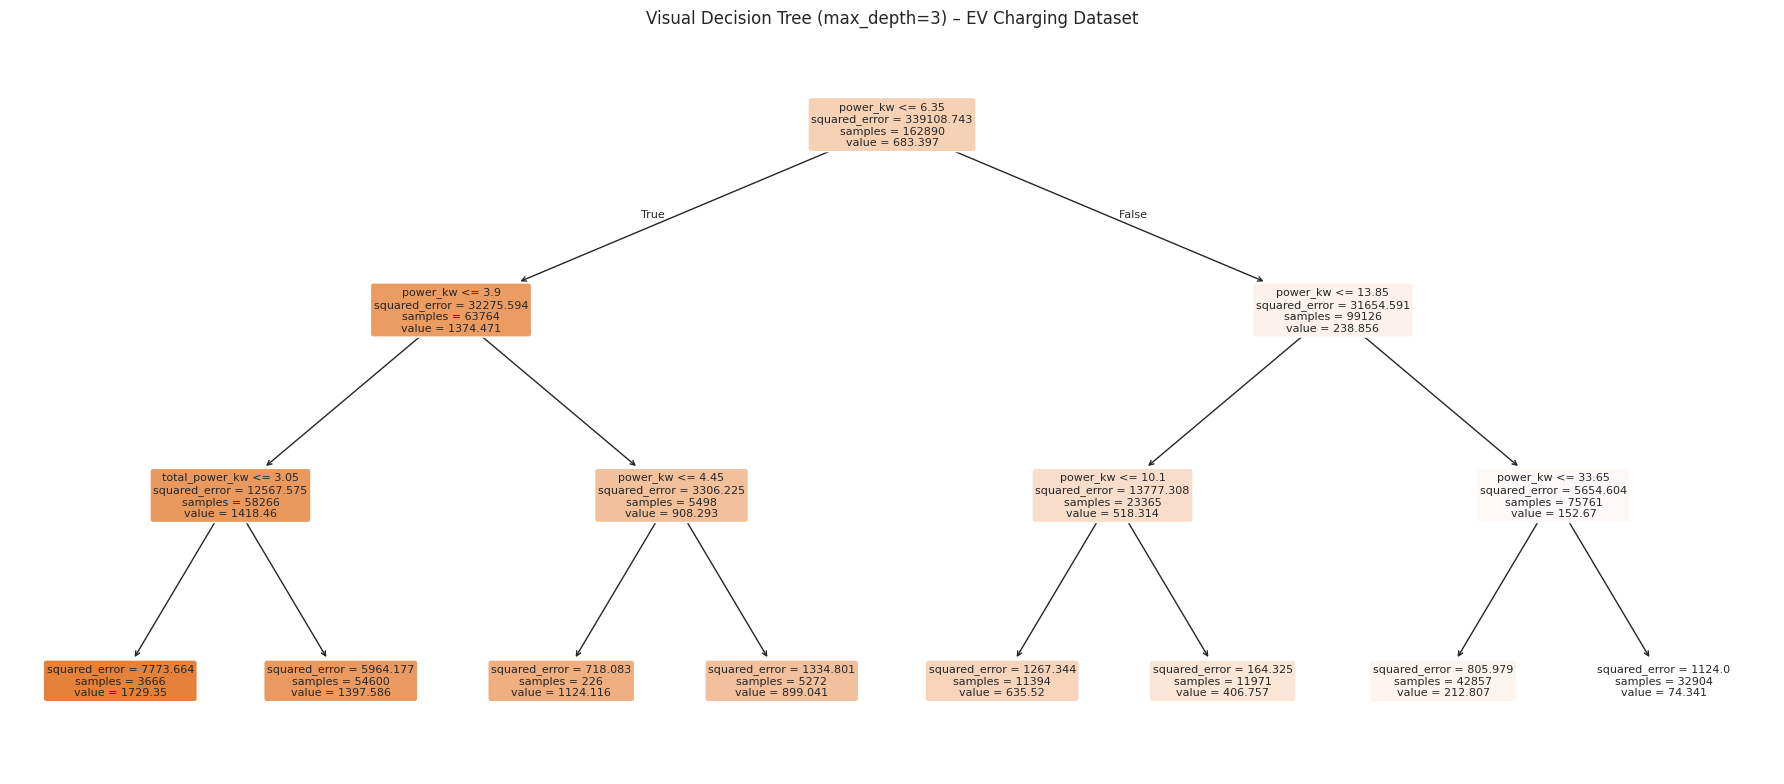

In [ ]:
dt = DecisionTreeRegressor(random_state=42)

dt_params = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10]
}

dt_grid = GridSearchCV(
    dt, dt_params,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)
dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_

dt_results = evaluate_model(
    "Decision Tree", best_dt,
    X_train, y_train, X_test, y_test
)
results.append(dt_results)

# ---- visual tree with our dataset (small depth) ----
vis_dt = DecisionTreeRegressor(max_depth=3, random_state=42)
vis_dt.fit(X_train, y_train)

plt.figure(figsize=(18, 8))
plot_tree(
    vis_dt,
    feature_names=X_encoded.columns,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Visual Decision Tree (max_depth=3) – EV Charging Dataset")
plt.tight_layout()
plt.show()

In [ ]:
rf_train_sample = X_train.sample(frac=0.3, random_state=42)
rf_y_sample = y_train.loc[rf_train_sample.index]
print("Random Forest tuning sample size:", rf_train_sample.shape)

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 5],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    rf, rf_params,
    n_iter=6,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rf_search.fit(rf_train_sample, rf_y_sample)
print("Best RF params:", rf_search.best_params_)

best_rf = RandomForestRegressor(
    **rf_search.best_params_,
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train, y_train)

rf_results = evaluate_model(
    "Random Forest", best_rf,
    X_train, y_train, X_test, y_test
)
results.append(rf_results)


Random Forest tuning sample size: (48867, 19)
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best RF params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

Random Forest
-------------
RMSE train: 1.257
RMSE test : 2.750
MAE test  : 0.267
R² test   : 1.000


Gradient Boosting tuning sample size: (48867, 19)
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best GB params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}

Gradient Boosting
-----------------
RMSE train: 1.555
RMSE test : 1.657
MAE test  : 0.391
R² test   : 1.000


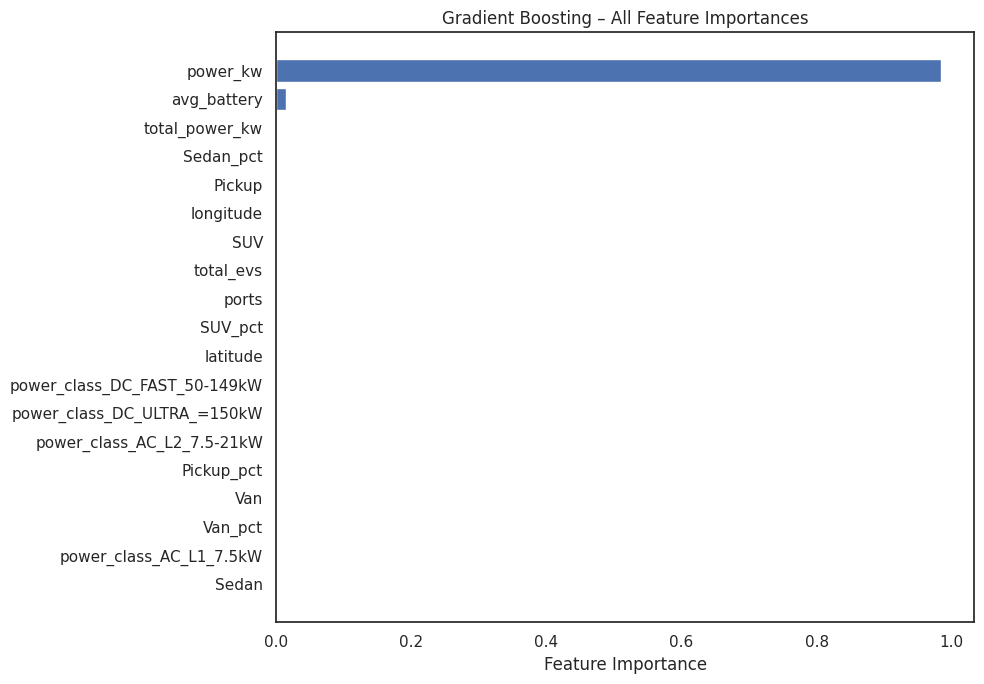

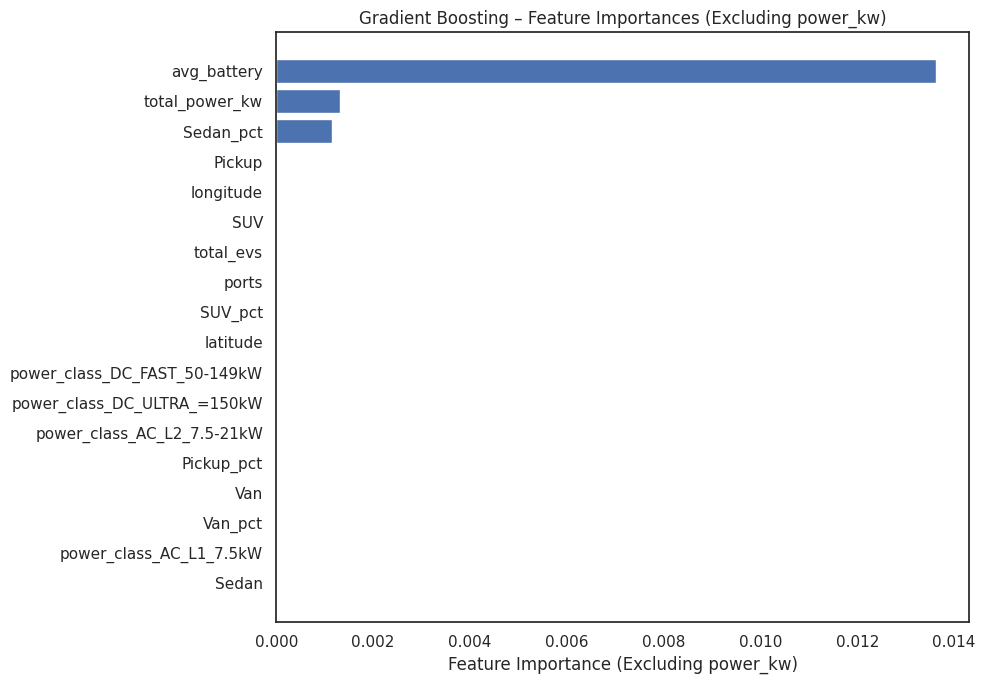

In [ ]:
gb_train_sample = X_train.sample(frac=0.3, random_state=42)
gb_y_sample = y_train.loc[gb_train_sample.index]
print("Gradient Boosting tuning sample size:", gb_train_sample.shape)

gbr = GradientBoostingRegressor(random_state=42)

gbr_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.03, 0.1],
    "max_depth": [2, 3]
}

gbr_grid = GridSearchCV(
    gbr, gbr_params,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)
gbr_grid.fit(gb_train_sample, gb_y_sample)
print("Best GB params:", gbr_grid.best_params_)

best_gbr = GradientBoostingRegressor(
    **gbr_grid.best_params_,
    random_state=42
)
best_gbr.fit(X_train, y_train)

gbr_results = evaluate_model(
    "Gradient Boosting", best_gbr,
    X_train, y_train, X_test, y_test
)
results.append(gbr_results)

# Gradient Boosting Feature Importances
importances_gbr = best_gbr.feature_importances_
feature_names_gbr = X_encoded.columns

# Sort features by importance
sorted_indices = np.argsort(importances_gbr)[::-1]
sorted_importances = importances_gbr[sorted_indices]
sorted_names = feature_names_gbr[sorted_indices]

# Plot all feature importances
plt.figure(figsize=(10, 7))
plt.barh(range(len(sorted_importances)), sorted_importances[::-1])
plt.yticks(range(len(sorted_importances)), sorted_names[::-1])
plt.xlabel("Feature Importance")
plt.title("Gradient Boosting – All Feature Importances")
plt.tight_layout()
plt.show()

# Plot feature importances excluding 'power_kw' for better visibility of other features
try:
    # Create a mask to exclude 'power_kw'
    mask = np.array([name != 'power_kw' for name in feature_names_gbr])

    importances_gbr_no_power_kw = importances_gbr[mask]
    feature_names_gbr_no_power_kw = feature_names_gbr[mask]

    # Sort the remaining features
    sorted_indices_no_power_kw = np.argsort(importances_gbr_no_power_kw)[::-1]
    sorted_importances_no_power_kw = importances_gbr_no_power_kw[sorted_indices_no_power_kw]
    sorted_names_no_power_kw = feature_names_gbr_no_power_kw[sorted_indices_no_power_kw]

    if len(sorted_importances_no_power_kw) > 0:
        plt.figure(figsize=(10, 7))
        plt.barh(range(len(sorted_importances_no_power_kw)), sorted_importances_no_power_kw[::-1])
        plt.yticks(range(len(sorted_importances_no_power_kw)), sorted_names_no_power_kw[::-1])
        plt.xlabel("Feature Importance (Excluding power_kw)")
        plt.title("Gradient Boosting – Feature Importances (Excluding power_kw)")
        plt.tight_layout()
        plt.show()
    else:
        print("No features remaining after excluding 'power_kw' for plotting.")

except ValueError:
    print("'power_kw' not found in feature names, skipping exclusion plot.")

In [ ]:
try:
    from xgboost import XGBRegressor

    xgb = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    xgb.fit(X_train, y_train)

    xgb_results = evaluate_model(
        "XGBoost", xgb,
        X_train, y_train, X_test, y_test
    )
    results.append(xgb_results)

except ImportError:
    xgb = None
    print("XGBoost not installed. Skipping.")


XGBoost
-------
RMSE train: 1.806
RMSE test : 1.863
MAE test  : 0.656
R² test   : 1.000


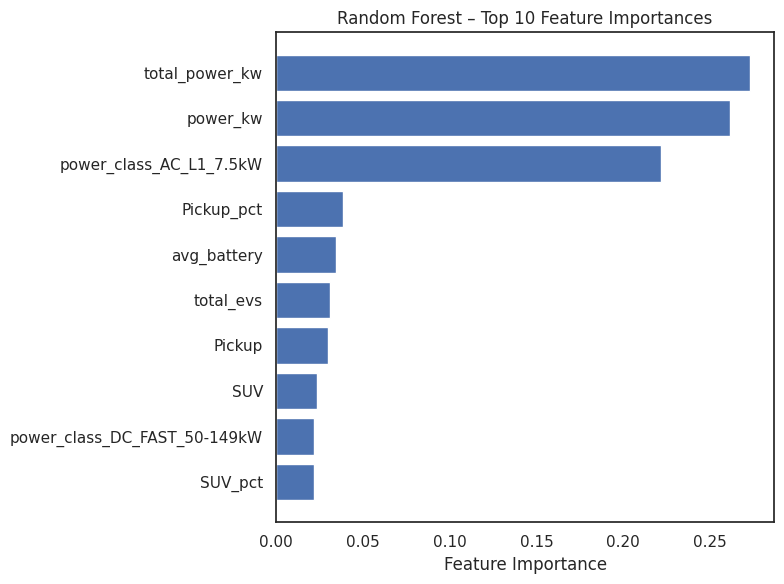

In [ ]:
#Random Foresr Top 10 Features
importances = best_rf.feature_importances_
feature_names = X_encoded.columns

indices = np.argsort(importances)[::-1]
top_n = 10
top_indices = indices[:top_n]
top_importances = importances[top_indices]
top_names = feature_names[top_indices]

plt.figure(figsize=(8, 6))
plt.barh(range(len(top_importances)), top_importances[::-1])
plt.yticks(range(len(top_importances)), top_names[::-1])
plt.xlabel("Feature Importance")
plt.title("Random Forest – Top 10 Feature Importances")
plt.tight_layout()
plt.show()

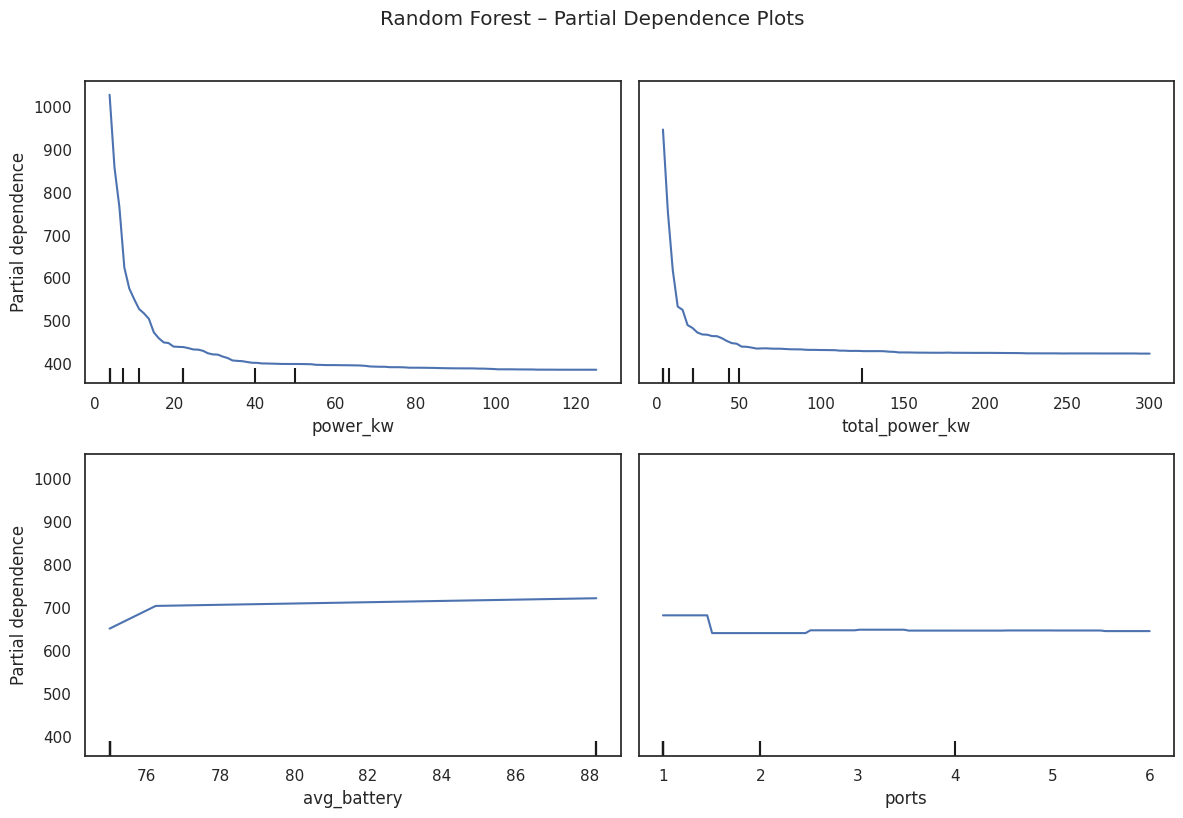

In [ ]:
features_for_pdp = [
    "power_kw",
    "total_power_kw",
    "avg_battery",
    "ports"
]

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

PartialDependenceDisplay.from_estimator(
    best_rf,
    X_encoded,
    features_for_pdp,
    kind="average",
    ax=ax
)

plt.suptitle("Random Forest – Partial Dependence Plots", y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
results_df = pd.DataFrame(results)
results_df.to_csv("tree_models_performance.csv", index=False)

print("\nSaved performance table → tree_models_performance.csv")
display(results_df)


Saved performance table → tree_models_performance.csv


,model,RMSE_train,RMSE_test,MAE_test,R2_test
0,Decision Tree,0.074863,0.465853,0.013546,0.999999
1,Random Forest,1.257460,2.749786,0.266740,0.999978
2,Gradient Boosting,1.554691,1.656691,0.391261,0.999992
3,XGBoost,1.806079,1.862893,0.655715,0.999990


**Reasoning**:
The `results` list contains the performance metrics for all models before and after including the new features. I need to convert this list into a pandas DataFrame to facilitate comparison and then display it to the user.



In [ ]:
results_df_new = pd.DataFrame(results)
# Drop duplicate model entries, keeping the last (most recent) run for each model name
results_df_new = results_df_new.drop_duplicates(subset=['model'], keep='last')
print("Model Performance Comparison (with and without new features, cleaned):")
display(results_df_new)

Model Performance Comparison (with and without new features, cleaned):


,model,RMSE_train,RMSE_test,MAE_test,R2_test
0,Decision Tree,0.074863,0.465853,0.013546,0.999999
1,Random Forest,1.257460,2.749786,0.266740,0.999978
2,Gradient Boosting,1.554691,1.656691,0.391261,0.999992
3,XGBoost,1.806079,1.862893,0.655715,0.999990


In [ ]:
y_pred_rf = best_rf.predict(X_test)
print("Random Forest predictions generated.")

Random Forest predictions generated.


In [ ]:
y_pred_rf_series = pd.Series(y_pred_rf, index=y_test.index)
sample_indices = y_test.sample(n=10, random_state=42).index
comparison_df = pd.DataFrame({
    'Actual': y_test.loc[sample_indices],
    'Predicted': y_pred_rf_series.loc[sample_indices]
})
print("Sample of Actual vs. Predicted Charging Times:")
display(comparison_df)

Sample of Actual vs. Predicted Charging Times:


,Actual,Predicted
94185,25.000000,25.409899
203215,204.545455,204.545455
30854,642.857143,642.857143
20549,409.090909,409.090909
92396,90.000000,90.000000
104892,409.090909,409.090909
88550,204.545455,204.545455
178804,1429.975430,1429.975430
133689,1429.975430,1429.975430
177843,1429.975430,1429.975430


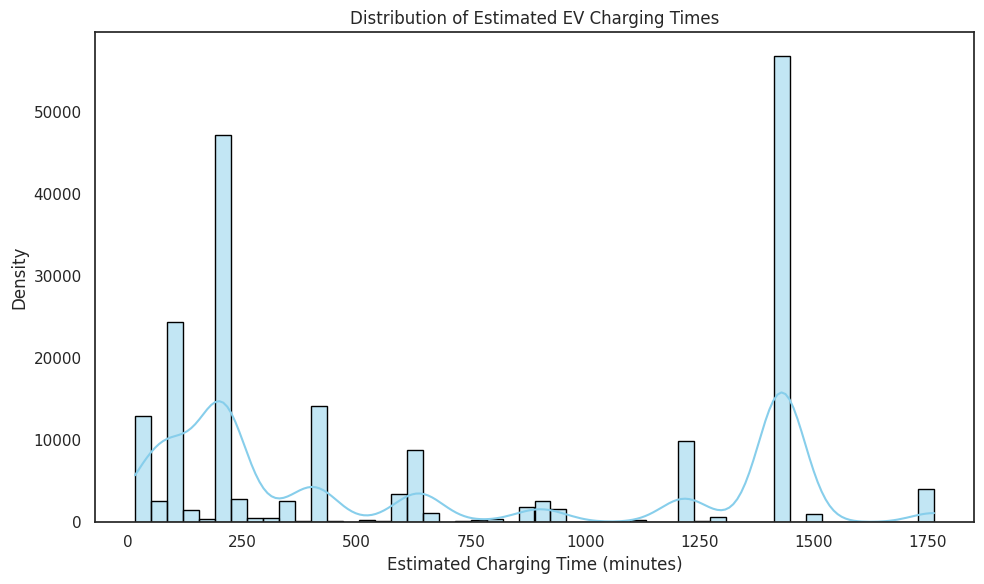

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df["charge_time_est_mins"], bins=50, kde=True, color='skyblue', edgecolor='black')
plt.xlabel("Estimated Charging Time (minutes)")
plt.ylabel("Density")
plt.title("Distribution of Estimated EV Charging Times")
plt.tight_layout()
plt.show()

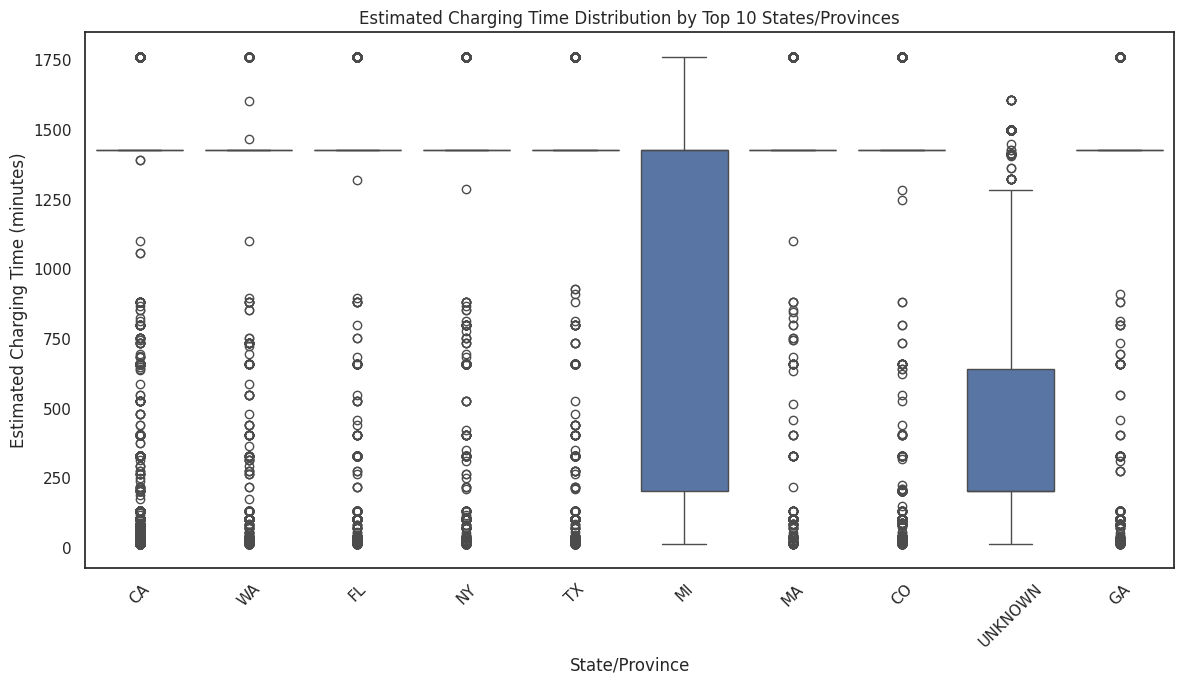

In [7]:
plt.figure(figsize=(12, 7))
sns.boxplot(
    x="state_province",
    y="charge_time_est_mins",
    data=df[df["state_province"].isin(
        df["state_province"].value_counts().head(10).index
    )]
)
plt.xlabel("State/Province")
plt.ylabel("Estimated Charging Time (minutes)")
plt.title("Estimated Charging Time Distribution by Top 10 States/Provinces")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

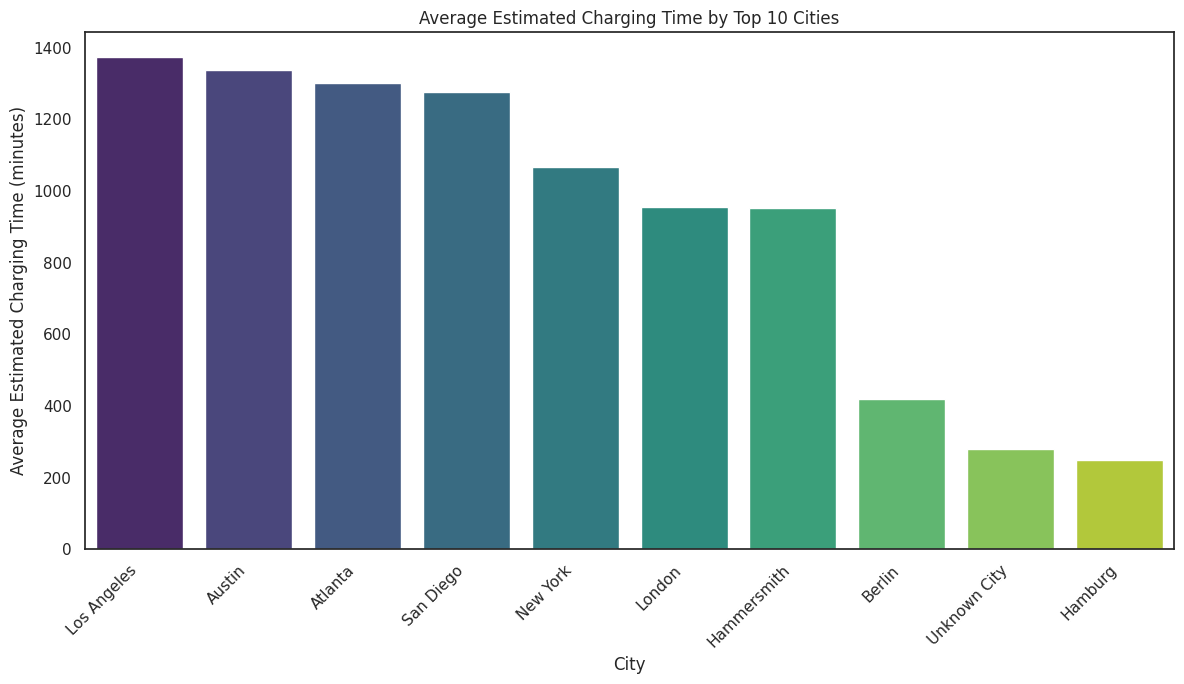

In [ ]:
top_10_cities = df['city'].value_counts().head(10).index
df_top_cities = df[df['city'].isin(top_10_cities)]

avg_charge_time_by_city = df_top_cities.groupby('city')['charge_time_est_mins'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=avg_charge_time_by_city.index, y=avg_charge_time_by_city.values, palette='viridis')
plt.xlabel("City")
plt.ylabel("Average Estimated Charging Time (minutes)")
plt.title("Average Estimated Charging Time by Top 10 Cities")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
top_n_cities = df['city'].value_counts().head(15).index.tolist()
df['city_top_N'] = df['city'].apply(lambda x: x if x in top_n_cities else 'Other')

print("Top 15 cities identified:", top_n_cities)
print("Value counts for new 'city_top_N' column:\n", df['city_top_N'].value_counts())

Top 15 cities identified: ['Unknown City', 'London', 'Los Angeles', 'Hammersmith', 'Berlin', 'San Diego', 'Atlanta', 'Austin', 'Hamburg', 'New York', 'OSLO', 'Irvine', 'Houston', 'Seattle', 'Coventry']
Value counts for new 'city_top_N' column:
 city_top_N
Other           167817
Unknown City     18434
London            7456
Los Angeles       2121
Hammersmith       1117
Berlin             816
San Diego          752
Atlanta            671
Austin             646
Hamburg            615
New York           547
OSLO               535
Irvine             528
Houston            522
Seattle            522
Coventry           514
Name: count, dtype: int64


In [ ]:
features_city = [
    col for col in core_features if col != target
] + [
    "latitude", "longitude", "city_top_N"
]
X_new_city = df[features_city].copy()

X_encoded_city = pd.get_dummies(X_new_city, drop_first=True)

clean_cols_city = (
    X_encoded_city.columns
    .astype(str)
    .str.replace(r"[<>[\]()]", "_", regex=True)
    .str.replace(r"__+", "_", regex=True)
    .str.strip("_")
)

X_encoded_city.columns = clean_cols_city

X_encoded_city = X_encoded_city.apply(pd.to_numeric, errors="coerce")
X_encoded_city = X_encoded_city.fillna(X_encoded_city.median())

print("X_encoded_city shape:", X_encoded_city.shape)
print("X_encoded_city head:")
display(X_encoded_city.head())

X_encoded_city shape: (203613, 22)
X_encoded_city head:


,power_kw,total_power_kw,ports,avg_battery,total_evs,latitude,longitude,city_top_N_Austin,city_top_N_Berlin,city_top_N_Coventry,...,city_top_N_Houston,city_top_N_Irvine,city_top_N_London,city_top_N_Los Angeles,city_top_N_New York,city_top_N_OSLO,city_top_N_Other,city_top_N_San Diego,city_top_N_Seattle,city_top_N_Unknown City
0,3.7,3.7,1,88.181818,11,34.040539,-118.271387,False,False,False,...,False,False,False,True,False,False,False,False,False,False
1,50.0,50.0,1,88.181818,11,34.059133,-118.248589,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,3.7,3.7,1,88.181818,11,38.576769,-121.495022,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,3.7,3.7,1,88.181818,11,34.145138,-118.152655,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,3.7,3.7,1,88.181818,11,34.145119,-118.150133,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [ ]:
X_train_city, X_test_city, y_train_city, y_test_city = train_test_split(
    X_encoded_city, y, test_size=0.2, random_state=42
)

print("Train shape (with city features):", X_train_city.shape, "| Test shape (with city features):", X_test_city.shape)

Train shape (with city features): (162890, 22) | Test shape (with city features): (40723, 22)


In [ ]:
best_rf_city = RandomForestRegressor(
    **rf_search.best_params_,
    random_state=42,
    n_jobs=-1
)
best_rf_city.fit(X_train_city, y_train_city)

print("Random Forest Regressor (with city features) re-trained successfully.")

Random Forest Regressor (with city features) re-trained successfully.


In [ ]:
rf_city_results = evaluate_model(
    "Random Forest (with city features)", best_rf_city,
    X_train_city, y_train_city, X_test_city, y_test_city
)
results.append(rf_city_results)


Random Forest (with city features)
----------------------------------
RMSE train: 2.007
RMSE test : 5.832
MAE test  : 0.742
R² test   : 1.000


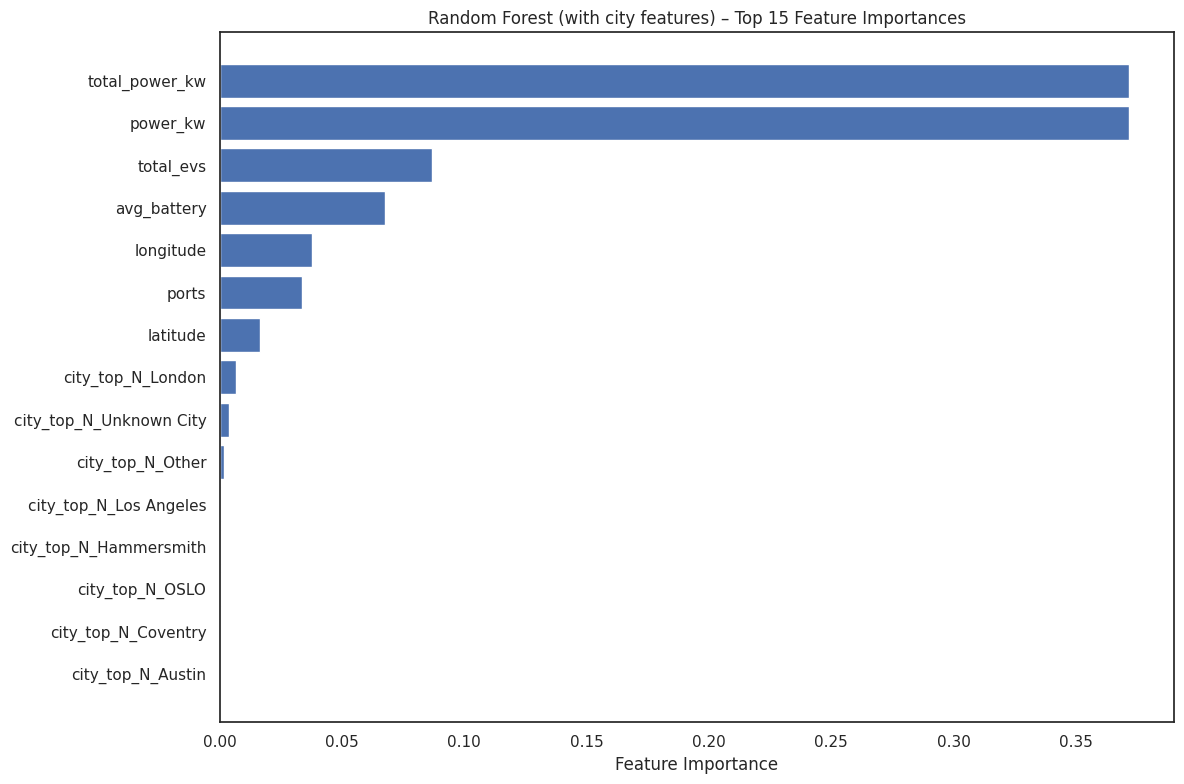

In [ ]:
importances_rf_city = best_rf_city.feature_importances_
feature_names_rf_city = X_encoded_city.columns

# Sort features by importance
sorted_indices_rf_city = np.argsort(importances_rf_city)[::-1]
sorted_importances_rf_city = importances_rf_city[sorted_indices_rf_city]
sorted_names_rf_city = feature_names_rf_city[sorted_indices_rf_city]

# Plot top N feature importances
top_n_plot = 15 # Plotting all features for better visibility of city impact
plt.figure(figsize=(12, 8))
plt.barh(range(top_n_plot), sorted_importances_rf_city[:top_n_plot][::-1])
plt.yticks(range(top_n_plot), sorted_names_rf_city[:top_n_plot][::-1])
plt.xlabel("Feature Importance")
plt.title("Random Forest (with city features) – Top {} Feature Importances".format(top_n_plot))
plt.tight_layout()
plt.show()


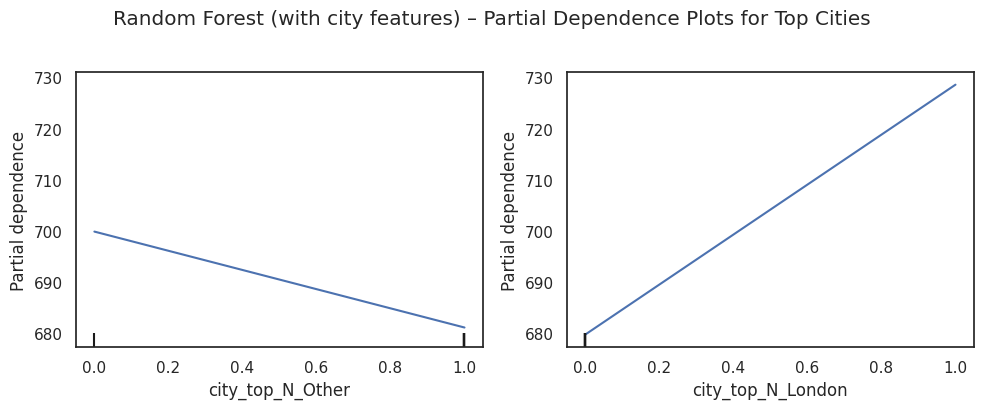

In [ ]:
city_features_for_pdp = [
    'city_top_N_Other',
    'city_top_N_London',
    'city_top_N_Unknown_City',
    'city_top_N_Los_Angeles',
    'city_top_N_New_York'
]

# Ensure these features exist in X_encoded_city
existing_city_features_for_pdp = [f for f in city_features_for_pdp if f in X_encoded_city.columns]

if len(existing_city_features_for_pdp) > 0:
    # Determine layout for subplots. Max 3 columns, adjust rows accordingly.
    n_features = len(existing_city_features_for_pdp)
    n_cols = min(n_features, 3)
    n_rows = (n_features + n_cols - 1) // n_cols # Ceiling division

    fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))

    # Flatten ax if it's a 2D array, for easier iteration
    if n_rows > 1 or n_cols > 1:
        ax = ax.flatten()
    else:
        ax = [ax] # Make it iterable for a single plot

    PartialDependenceDisplay.from_estimator(
        best_rf_city,
        X_encoded_city,
        features=existing_city_features_for_pdp,
        kind="average",
        ax=ax
    )

    # Hide any unused subplots
    for i in range(n_features, len(ax)):
        fig.delaxes(ax[i])

    plt.suptitle("Random Forest (with city features) – Partial Dependence Plots for Top Cities", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No selected city features found in the encoded dataframe for PDPs.")

In [ ]:
results_df_with_city = pd.DataFrame(results)
print("\nUpdated Model Performance Comparison:")
display(results_df_with_city)


Updated Model Performance Comparison:


,model,RMSE_train,RMSE_test,MAE_test,R2_test
0,Decision Tree,0.074863,0.465853,0.013546,0.999999
1,Random Forest,1.257460,2.749786,0.266740,0.999978
2,Gradient Boosting,1.554691,1.656691,0.391261,0.999992
3,XGBoost,1.806079,1.862893,0.655715,0.999990
4,Random Forest (with city features),2.006735,5.832311,0.742362,0.999899
